**Nama:** Selva Tri Martadinata  
**Mata Kuliah:** Analisis Numerik  
**Tugas:** Regresi dan Pencarian Akar  

## **Analisis Regresi dan Pencarian Break-Even Point pada Lima Gerai Donat**


Analisis ini dilakukan terhadap data laba/rugi harian dari lima gerai donat dengan strategi marketing yang berbeda, yaitu Gerai A, Gerai B, Gerai C, Gerai D, dan Gerai E.

Analisis yang dilakukan meliputi:
1. Visualisasi hubungan jumlah penjualan dengan revenue.
2. Penerapan regresi untuk mengetahui bentuk tren revenue berdasarkan volume penjualan.
3. Pencarian titik Break-Even Point (BEP) menggunakan hasil regresi dan metode pencarian akar.
4. Perbandingan hasil BEP dari masing-masing gerai.

# **1. IMPORT LIBRARY & MEMBACA DATASET**
Library yang digunakan adalah pandas untuk membaca dan mengolah dataset, numpy untuk melakukan perhitungan numerik, dan matplotlib untuk membuat visualisasi data.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Membaca file CSV
df = pd.read_csv('/content/sintesis_data_donat_harian.csv')

print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (450, 8)


,Tanggal,Gerai,Harga Jual (Rp),Jumlah Terjual (Unit),Pendapatan Kotor (Rp),Biaya Variabel (Rp),Fixed Cost Harian (Rp),Balance (Rp)
0,2026-01-01,Gerai A,25000,87,2175000,739500,1683333,-247833
1,2026-01-02,Gerai A,25000,81,2025000,688500,1683333,-346833
2,2026-01-03,Gerai A,25000,110,2750000,935000,1683333,131667
3,2026-01-04,Gerai A,25000,119,2975000,1011500,1683333,280167
4,2026-01-05,Gerai A,25000,94,2350000,799000,1683333,-132333


Data terdiri dari catatan transaksi harian dari lima gerai. Kolom Jumlah Terjual (Unit) digunakan sebagai variabel volume penjualan, sedangkan Pendapatan Kotor (Rp) digunakan sebagai nilai revenue.

Kolom Balance (Rp) digunakan untuk menentukan kondisi laba atau rugi dan menjadi dasar dalam pencarian titik Break-Even Point.

In [78]:
# Mengecek apakah terdapat nilai kosong pada setiap kolom
print("Jumlah nilai kosong:")
print(df.isnull().sum())

# Menampilkan daftar nama gerai yang terdapat dalam dataset
print("Daftar gerai:")
print(df['Gerai'].unique())

# Menghitung jumlah data untuk setiap gerai
print("\nJumlah data setiap gerai:")
print(df['Gerai'].value_counts())

Jumlah nilai kosong:
Tanggal                   0
Gerai                     0
Harga Jual (Rp)           0
Jumlah Terjual (Unit)     0
Pendapatan Kotor (Rp)     0
Biaya Variabel (Rp)       0
Fixed Cost Harian (Rp)    0
Balance (Rp)              0
dtype: int64
Daftar gerai:
['Gerai A' 'Gerai B' 'Gerai C' 'Gerai D' 'Gerai E']

Jumlah data setiap gerai:
Gerai
Gerai A    90
Gerai B    90
Gerai C    90
Gerai D    90
Gerai E    90
Name: count, dtype: int64


# **2. Visualisasi Jumlah Penjualan vs Revenue**

Pada tahap kedua dilakukan visualisasi hubungan antara jumlah donat yang terjual dengan pendapatan kotor (revenue).

Variabel yang digunakan adalah:
- Sumbu X: Jumlah Terjual (Unit)
- Sumbu Y: Pendapatan Kotor (Rp)

Visualisasi dibuat untuk mengetahui pola hubungan antara volume penjualan dengan revenue pada masing-masing gerai.

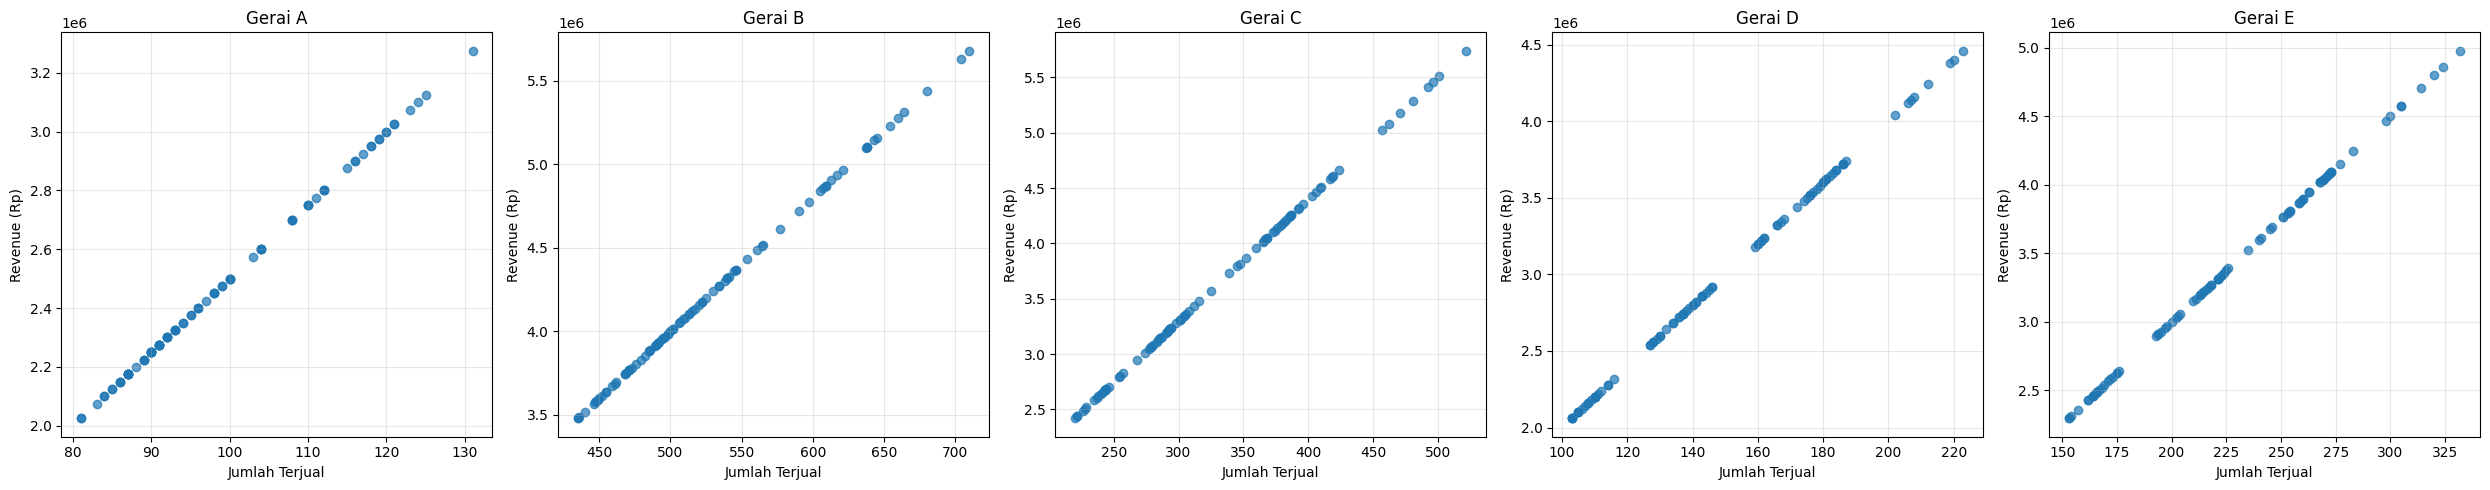

In [79]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Mengambil daftar gerai
gerai_list = ['Gerai A', 'Gerai B', 'Gerai C', 'Gerai D', 'Gerai E']
for ax, gerai in zip(axes, gerai_list):

    # Mengambil data berdasarkan nama gerai
    data_gerai = df[df['Gerai'] == gerai]

    # Membuat scatter plot
    ax.scatter(
        data_gerai['Jumlah Terjual (Unit)'],
        data_gerai['Pendapatan Kotor (Rp)'],
        alpha=0.7
    )

    # Memberikan judul
    ax.set_title(gerai)

    # Memberikan label sumbu X
    ax.set_xlabel('Jumlah Terjual')

    # Memberikan label sumbu Y
    ax.set_ylabel('Revenue (Rp)')

    # Menambahkan grid
    ax.grid(True, alpha=0.3)

# Mengatur jarak antar grafik
plt.tight_layout()

# Menampilkan grafik
plt.show()

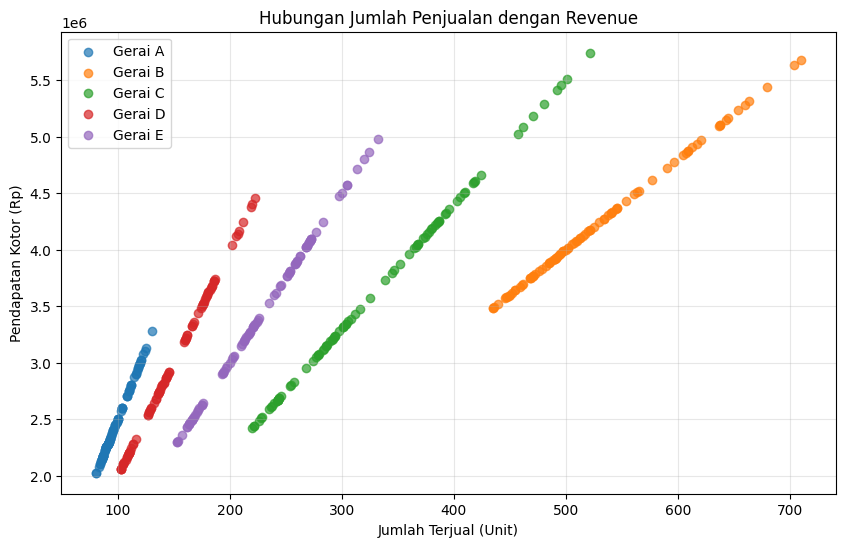

In [80]:
plt.figure(figsize=(10, 6))
gerai_list = df['Gerai'].unique()

for gerai in gerai_list:
    data_gerai = df[df['Gerai'] == gerai]

    plt.scatter(
        data_gerai['Jumlah Terjual (Unit)'],
        data_gerai['Pendapatan Kotor (Rp)'],
        label=gerai,
        alpha=0.7
    )

plt.title('Hubungan Jumlah Penjualan dengan Revenue')
plt.xlabel('Jumlah Terjual (Unit)')
plt.ylabel('Pendapatan Kotor (Rp)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Dapat dilihat dari grafik diatas menunjukkan bahwa hubungan antara jumlah donat yang terjual dengan revenue pada masing-masing gerai.

Pada seluruh gerai terlihat bahwa titik-titik data membentuk pola garis lurus yang meningkat dari kiri ke kanan. Artinya, ketika jumlah donat yang terjual bertambah, revenue juga bertambah.

Pola tersebut menunjukkan bahwa hubungan antara volume penjualan dan revenue cenderung linear.

Secara konsep, revenue dihitung menggunakan:

**Revenue = Harga Jual × Jumlah Terjual**

Contohnya pada Gerai A, harga jual satu donat adalah Rp25.000. Jika terjual X donat, maka:

Revenue = 25.000 × X

Misalnya jumlah penjualan adalah 100 unit:

Revenue = 25.000 × 100
Revenue = Rp2.500.000

Karena harga jual tetap, setiap penambahan 1 unit penjualan akan meningkatkan revenue sebesar Rp25.000. Hal inilah yang menyebabkan grafik Gerai A membentuk garis lurus.

Hal yang sama berlaku pada gerai lainnya, tetapi dengan harga jual yang berbeda.

# **3. Regresi Jumlah Penjualan terhadap Revenue**

Selanjutnya dilakukan analisis regresi untuk mengetahui bentuk hubungan antara jumlah penjualan dan revenue.

Model yang digunakan adalah regresi linear:

Revenue = a + bX

dengan:
- Y = revenue
- X = jumlah donat terjual
- a = intercept
- b = koefisien regresi atau kemiringan garis

Tujuan regresi pada tahap ini adalah mendapatkan persamaan matematis yang dapat digunakan untuk menggambarkan tren revenue berdasarkan volume penjualan.

Regresi linear dipilih karena hasil visualisasi sebelumnya menunjukkan bahwa hubungan jumlah penjualan dan revenue membentuk pola garis lurus.

In [81]:
# Dictionary untuk menyimpan hasil regresi
hasil_regresi = {}

# Melakukan regresi pada setiap gerai
for gerai in gerai_list:

    # Mengambil data gerai
    data_gerai = df[df['Gerai'] == gerai]

    # Variabel X = jumlah penjualan
    X = data_gerai['Jumlah Terjual (Unit)'].values

    # Variabel Y = revenue
    Y = data_gerai['Pendapatan Kotor (Rp)'].values

    # Menghitung jumlah data
    n = len(X)

    # Menghitung koefisien b
    b = (
        n * np.sum(X * Y)
        - np.sum(X) * np.sum(Y)
    ) / (
        n * np.sum(X**2)
        - np.sum(X)**2
    )

    # Menghitung intercept a
    a = np.mean(Y) - b * np.mean(X)

    # Menghitung nilai prediksi
    Y_pred = a + b * X

    # Menghitung R²
    ss_res = np.sum((Y - Y_pred)**2)
    ss_tot = np.sum((Y - np.mean(Y))**2)

    r2 = 1 - (ss_res / ss_tot)

    # Menyimpan hasil
    hasil_regresi[gerai] = {
        'a': a,
        'b': b,
        'r2': r2
    }

# Menampilkan hasil
for gerai in gerai_list:

    hasil = hasil_regresi[gerai]

    print(f"\n{gerai}")
    print(f"Persamaan : Y = {hasil['a']:.2f} + {hasil['b']:.2f}X")
    print(f"R²        : {hasil['r2']:.4f}")


Gerai A
Persamaan : Y = 0.00 + 25000.00X
R²        : 1.0000

Gerai B
Persamaan : Y = 0.00 + 8000.00X
R²        : 1.0000

Gerai C
Persamaan : Y = 0.00 + 11000.00X
R²        : 1.0000

Gerai D
Persamaan : Y = -0.00 + 20000.00X
R²        : 1.0000

Gerai E
Persamaan : Y = 0.00 + 15000.00X
R²        : 1.0000


Hasil regresi menunjukkan bahwa seluruh gerai memiliki pola hubungan linear antara jumlah penjualan dan revenue.

Pada Gerai A diperoleh persamaan:

Y = 25.000X

Artinya, setiap penambahan 1 unit penjualan diperkirakan meningkatkan revenue sebesar Rp25.000.

Karena harga jual setiap gerai tetap, setiap tambahan satu unit penjualan akan meningkatkan revenue sebesar harga jual gerai tersebut mengikuti perhitungan harga jual dikalikan jumlah produk yang terjual.

Nilai R² sebesar 1 menunjukkan bahwa model linear dapat menjelaskan hubungan revenue dengan jumlah penjualan secara sempurna.

# **4. Pencarian Break-Even Point (BEP)**

Setelah mendapatkan model regresi revenue, tahap berikutnya adalah mencari Break-Even Point (BEP).

Break-Even Point adalah kondisi ketika pendapatan sama dengan total biaya sehingga laba/rugi bernilai nol.

Dalam dataset terdapat kolom `Balance (Rp)` yang menunjukkan selisih antara revenue dengan biaya yaitu kondisi laba/rugi.

Oleh karena itu, untuk mencari BEP digunakan hubungan antara jumlah penjualan (X) dengan Balance (Y).

Model regresi yang digunakan adalah:

**Balance = a + bX**

dengan:

X = jumlah penjualan
a = intercept regresi
b = koefisien regresi

Break-Even Point dicari ketika:

Balance = 0

Maka:

0 = a + bX

Untuk mencari X:

bX = -a

Sehingga akar persamaan dapat dicari dengan:

X_BEP = -a / b

Nilai X_BEP merupakan jumlah penjualan yang diperlukan agar gerai mencapai titik impas.

In [82]:
# Dictionary untuk menyimpan hasil regresi Balance
hasil_balance = {}

# Melakukan regresi Balance terhadap jumlah penjualan
for gerai in gerai_list:

    # Mengambil data gerai
    data_gerai = df[df['Gerai'] == gerai]

    # X = jumlah penjualan
    X = data_gerai['Jumlah Terjual (Unit)'].values

    # Y = Balance
    Y = data_gerai['Balance (Rp)'].values

    # Menghitung koefisien regresi
    n = len(X)

    b = (
        n * np.sum(X * Y)
        - np.sum(X) * np.sum(Y)
    ) / (
        n * np.sum(X**2)
        - np.sum(X)**2
    )

    # Menghitung intercept
    a = np.mean(Y) - b * np.mean(X)

    # Menyimpan hasil
    hasil_balance[gerai] = {
        'a': a,
        'b': b
    }

# Menampilkan persamaan
for gerai in gerai_list:

    a = hasil_balance[gerai]['a']
    b = hasil_balance[gerai]['b']

    print(f"{gerai}:")
    print(f"Balance = {a:.2f} + {b:.2f}X")

Gerai A:
Balance = -1683333.00 + 16500.00X
Gerai B:
Balance = -733333.00 + 3840.00X
Gerai C:
Balance = -1733333.00 + 6160.00X
Gerai D:
Balance = -2666666.00 + 12800.00X
Gerai E:
Balance = -800000.00 + 8700.00X


Hasil regresi menunjukkan bahwa setiap penambahan jumlah penjualan akan meningkatkan nilai Balance pada masing-masing gerai. Persamaan regresi ini kemudian digunakan untuk menentukan titik BEP, yaitu saat nilai Balance = 0. Semakin besar nilai BEP, semakin banyak unit yang harus terjual untuk mencapai kondisi impas.


### **Contoh Perhitungan BEP Gerai A**

Hasil regresi Balance untuk Gerai A adalah:

Balance = -1.683.333 + 16.500X

BEP terjadi ketika Balance = 0.

Maka:

0 = -1.683.333 + 16.500X

16.500X = 1.683.333

X = 1.683.333 / 16.500

X = 102,02

Jadi, titik Break-Even Point Gerai A berada pada sekitar 102,02 unit penjualan.

Karena jumlah produk yang dijual harus berupa bilangan bulat, maka diperlukan minimal:

103 unit per hari

untuk melewati titik impas.

In [83]:
# Fungsi untuk mencari akar menggunakan metode Bisection
def bisection(f, a, b, tol=1e-6, max_iter=100):

    # Menghitung nilai fungsi pada batas bawah
    fa = f(a)

    # Menghitung nilai fungsi pada batas atas
    fb = f(b)

    # Memastikan terdapat akar dalam interval
    if fa * fb > 0:
        raise ValueError("Interval tidak mengandung akar.")

    # Melakukan iterasi
    for i in range(max_iter):

        # Menghitung titik tengah
        c = (a + b) / 2

        # Menghitung nilai fungsi di titik tengah
        fc = f(c)

        # Jika nilai fungsi sudah sangat dekat dengan nol,
        # maka akar dianggap sudah ditemukan
        if abs(fc) < tol:
            return c, i + 1

        # Menentukan interval baru
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc

    # Mengembalikan hasil jika iterasi maksimum tercapai
    return c, max_iter

In [84]:
# Dictionary untuk menyimpan hasil BEP
hasil_bep = {}

# Melakukan pencarian akar untuk setiap gerai
for gerai in gerai_list:

    # Mengambil nilai a dan b dari regresi Balance
    a = hasil_balance[gerai]['a']
    b = hasil_balance[gerai]['b']

    # Membuat fungsi Balance
    def fungsi_balance(x, a=a, b=b):
        return a + b * x

    # Mengambil data gerai
    data_gerai = df[df['Gerai'] == gerai]

    # Menentukan interval pencarian
    batas_bawah = 0
    batas_atas = data_gerai['Jumlah Terjual (Unit)'].max() * 2

    # Mencari akar dengan metode Bisection
    akar, iterasi = bisection(
        fungsi_balance,
        batas_bawah,
        batas_atas
    )

    # Menyimpan hasil
    hasil_bep[gerai] = {
        'bep': akar,
        'iterasi': iterasi
    }

# Menampilkan hasil
for gerai in gerai_list:

    print(
        f"{gerai}: "
        f"BEP = {hasil_bep[gerai]['bep']:.2f} unit, "
        f"Iterasi = {hasil_bep[gerai]['iterasi']}"
    )

Gerai A: BEP = 102.02 unit, Iterasi = 39
Gerai B: BEP = 190.97 unit, Iterasi = 39
Gerai C: BEP = 281.39 unit, Iterasi = 41
Gerai D: BEP = 208.33 unit, Iterasi = 41
Gerai E: BEP = 91.95 unit, Iterasi = 41


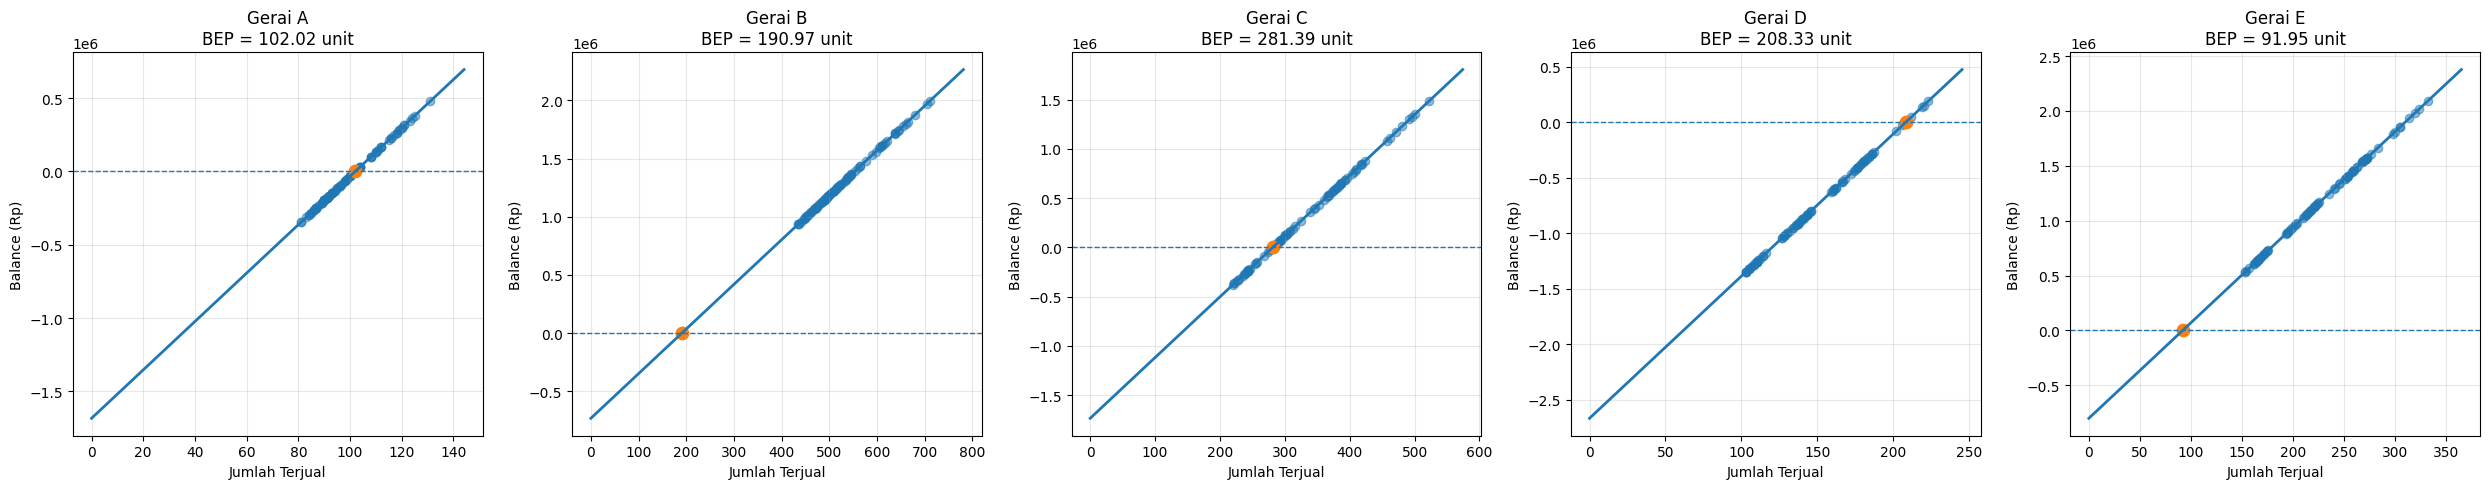

In [85]:
# Membuat 5 grafik dalam satu baris
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Membuat grafik untuk setiap gerai
for ax, gerai in zip(axes, gerai_list):

    # Mengambil data
    data_gerai = df[df['Gerai'] == gerai]

    X = data_gerai['Jumlah Terjual (Unit)'].values
    Y = data_gerai['Balance (Rp)'].values

    # Mengambil persamaan regresi
    a = hasil_balance[gerai]['a']
    b = hasil_balance[gerai]['b']

    # Mengambil BEP
    bep = hasil_bep[gerai]['bep']

    # Membuat garis regresi
    X_line = np.linspace(0, max(X.max(), bep) * 1.1, 100)
    Y_line = a + b * X_line

    # Data aktual
    ax.scatter(X, Y, alpha=0.5)

    # Garis regresi
    ax.plot(X_line, Y_line, linewidth=2)

    # Garis Balance = 0
    ax.axhline(0, linestyle='--', linewidth=1)

    # Titik BEP
    ax.scatter(bep, 0, s=80)

    # Judul
    ax.set_title(f'{gerai}\nBEP = {bep:.2f} unit')

    # Label
    ax.set_xlabel('Jumlah Terjual')

    ax.set_ylabel('Balance (Rp)')

    # Grid
    ax.grid(True, alpha=0.3)

# Mengatur jarak grafik
plt.tight_layout()

# Menampilkan
plt.show()

Pada grafik diatas, garis regresi menunjukkan hubungan antara jumlah penjualan dengan Balance.

Garis horizontal pada Balance = 0 menunjukkan kondisi titik impas.

Titik perpotongan antara garis regresi dengan garis Balance = 0 merupakan Break-Even Point.

Jika jumlah penjualan berada di bawah titik BEP, nilai Balance berada pada kondisi negatif sehingga gerai mengalami kerugian.

Jika jumlah penjualan berada di atas titik BEP, nilai Balance menjadi positif sehingga gerai mulai memperoleh keuntungan.

Dengan demikian, pencarian BEP dapat dipandang sebagai proses mencari akar dari fungsi Balance:

f(X) = Balance = 0

Hasil pencarian akar menunjukkan bahwa setiap gerai memiliki jumlah penjualan minimum yang berbeda untuk mencapai titik impas.

In [86]:
# Membuat list untuk menyimpan seluruh hasil analisis
hasil_akhir = []

# Melakukan perulangan untuk setiap gerai
for gerai in gerai_list:

    # Mengambil hasil regresi revenue
    a_revenue = hasil_regresi[gerai]['a']
    b_revenue = hasil_regresi[gerai]['b']
    r2 = hasil_regresi[gerai]['r2']

    # Mengambil hasil regresi balance
    a_balance = hasil_balance[gerai]['a']
    b_balance = hasil_balance[gerai]['b']

    # Mengambil hasil BEP dari metode Bisection
    bep = hasil_bep[gerai]['bep']

    # Membulatkan BEP ke atas karena jumlah penjualan
    # harus berupa bilangan bulat
    minimal_unit = np.ceil(bep)

    # Membuat persamaan revenue
    persamaan_revenue = (
        f"Y = {a_revenue:,.2f} + "
        f"{b_revenue:,.2f}X"
    )

    # Membuat persamaan balance
    persamaan_balance = (
        f"Y = {a_balance:,.2f} + "
        f"{b_balance:,.2f}X"
    )

    # Menyimpan semua hasil ke dalam dictionary
    hasil_akhir.append({
        'Gerai': gerai,
        'Persamaan Revenue': persamaan_revenue,
        'R²': r2,
        'Persamaan Balance': persamaan_balance,
        'BEP (Unit)': bep,
        'Minimal Penjualan (Unit)': minimal_unit
    })

# Mengubah hasil menjadi DataFrame
tabel_hasil = pd.DataFrame(hasil_akhir)

# Membulatkan nilai R² dan BEP agar lebih mudah dibaca
tabel_hasil['R²'] = tabel_hasil['R²'].round(4)
tabel_hasil['BEP (Unit)'] = tabel_hasil['BEP (Unit)'].round(2)

# Menampilkan tabel hasil akhir dengan format yang lebih rapi
display(
    tabel_hasil.style
    .format({
        'R²': '{:.4f}',
        'BEP (Unit)': '{:.2f}',
        'Minimal Penjualan (Unit)': '{:.0f}'
    })
    .set_caption('Tabel Hasil Analisis Regresi dan Break-Even Point')
)

,Gerai,Persamaan Revenue,R²,Persamaan Balance,BEP (Unit),Minimal Penjualan (Unit)
0,Gerai A,"Y = 0.00 + 25,000.00X",1.0000,"Y = -1,683,333.00 + 16,500.00X",102.02,103
1,Gerai B,"Y = 0.00 + 8,000.00X",1.0000,"Y = -733,333.00 + 3,840.00X",190.97,191
2,Gerai C,"Y = 0.00 + 11,000.00X",1.0000,"Y = -1,733,333.00 + 6,160.00X",281.39,282
3,Gerai D,"Y = -0.00 + 20,000.00X",1.0000,"Y = -2,666,666.00 + 12,800.00X",208.33,209
4,Gerai E,"Y = 0.00 + 15,000.00X",1.0000,"Y = -800,000.00 + 8,700.00X",91.95,92


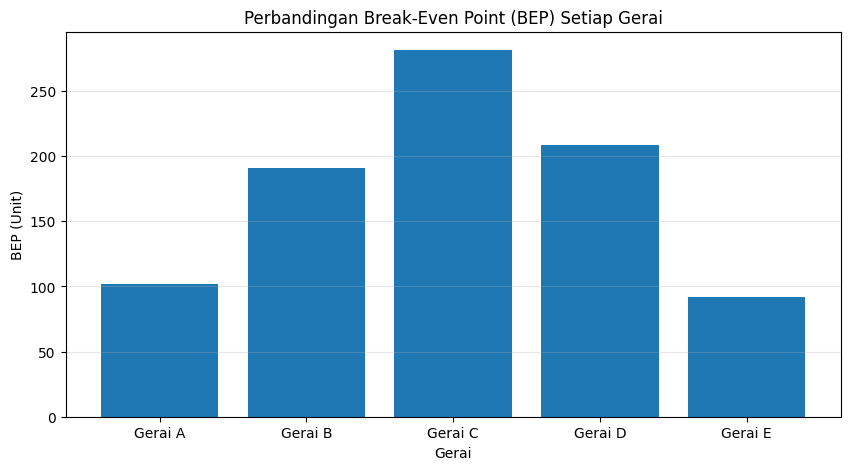

In [87]:
# Grafik perbandingan BEP setiap gerai

plt.figure(figsize=(10, 5))

plt.bar(
    tabel_hasil['Gerai'],
    tabel_hasil['BEP (Unit)']
)

plt.title('Perbandingan Break-Even Point (BEP) Setiap Gerai')
plt.xlabel('Gerai')
plt.ylabel('BEP (Unit)')
plt.grid(axis='y', alpha=0.3)

plt.show()

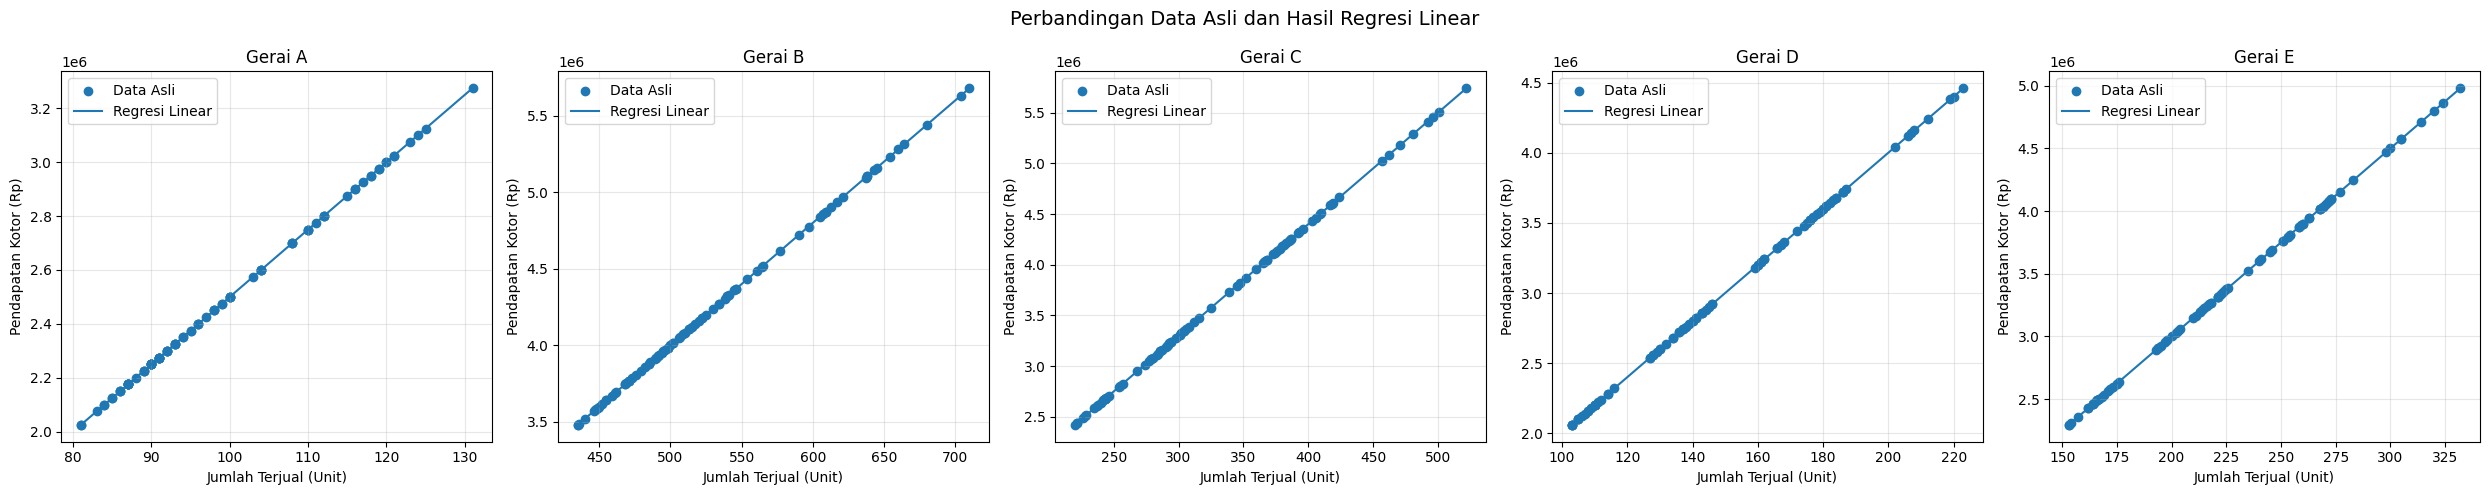

In [88]:
# Grafik perbandingan data asli dengan hasil regresi

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for i, gerai in enumerate(gerai_list):

    data_gerai = df[df['Gerai'] == gerai]

    X = data_gerai['Jumlah Terjual (Unit)'].values
    Y = data_gerai['Pendapatan Kotor (Rp)'].values

    # Mengambil hasil regresi dari perhitungan sebelumnya
    a = hasil_regresi[gerai]['a']
    b = hasil_regresi[gerai]['b']

    # Membuat nilai X untuk garis regresi
    X_garis = np.linspace(X.min(), X.max(), 100)

    # Menghitung nilai Y berdasarkan persamaan regresi
    Y_garis = a + b * X_garis

    # Data asli
    axes[i].scatter(
        X,
        Y,
        label='Data Asli'
    )

    # Garis hasil regresi
    axes[i].plot(
        X_garis,
        Y_garis,
        label='Regresi Linear'
    )

    axes[i].set_title(gerai)
    axes[i].set_xlabel('Jumlah Terjual (Unit)')
    axes[i].set_ylabel('Pendapatan Kotor (Rp)')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.suptitle(
    'Perbandingan Data Asli dan Hasil Regresi Linear',
    fontsize=14
)

plt.tight_layout()
plt.show()

### **Kesimpulan**

Berdasarkan hasil regresi dan pencarian akar menggunakan metode Bisection, diperoleh nilai BEP yang berbeda pada masing-masing gerai. Gerai E memiliki BEP sekitar 92 unit, Gerai A sekitar 102 unit, Gerai B sekitar 191 unit, Gerai D sekitar 208 unit, dan Gerai C sekitar 281 unit.

Hasil tersebut menunjukkan bahwa Gerai E dan Gerai A mencapai titik impas pada jumlah penjualan yang lebih rendah, sedangkan Gerai C membutuhkan jumlah penjualan yang paling besar untuk mencapai kondisi impas. Gerai B dan Gerai D berada di antara keduanya. Perbedaan nilai BEP ini berkaitan dengan perbedaan pola pendapatan dan biaya pada masing-masing gerai.

Secara keseluruhan, hasil regresi dapat digunakan untuk menggambarkan hubungan antara jumlah penjualan dengan pendapatan atau balance, sedangkan metode Bisection digunakan untuk mencari titik ketika balance sama dengan nol. Dengan demikian, analisis ini dapat menunjukkan perkiraan jumlah unit donat yang perlu terjual oleh setiap gerai untuk mencapai kondisi Break-Even Point (BEP).
